Всего компонент (блоков) найдено: 427
Отфильтровано и нарисовано: 11
Параметры: Dilation=3, Std Multiplier=1.00, MinSize=200


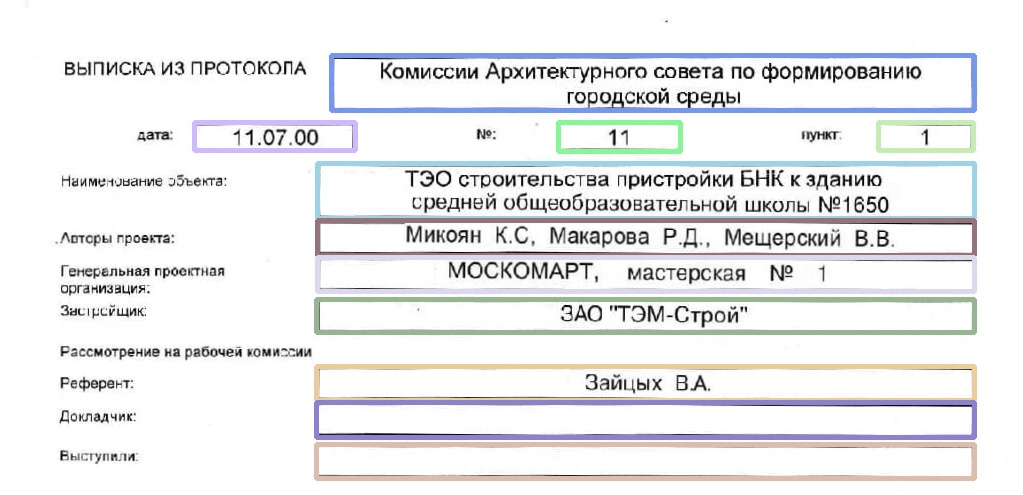

In [6]:
import cv2
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from pathlib import Path
import random
from scipy.ndimage import morphology as scipy_morph, label

# ======================= MAIN EXTRACTION FUNCTION ==================================
def box_extraction(img_path, dilation_size, std_multiplier, min_size):
    # 1. Read in grayscale
    img = cv2.imread(img_path, 0)
    
    # === LOGIC FROM STACKOVERFLOW ===
    # 2. Inner morphological gradient.
    # scipy expects a specific footprint. We create a 3x3 matrix of 1s.
    footprint = np.ones((dilation_size, dilation_size), dtype=bool)
    
    # dilate the image and subtract the original to get the 'inner gradient' (edges)
    dilated = scipy_morph.grey_dilation(img, footprint=footprint)
    im = dilated.astype(np.int32) - img.astype(np.int32)

    # 3. Binarize using Mean + Std (Dynamic threshold)
    mean, std = im.mean(), im.std()
    t = mean + (std * std_multiplier) # We allow tuning the multiplier
    
    # Apply the threshold
    im[im < t] = 0
    im[im >= t] = 1

    # 4. Connected components (Scipy label)
    lbl, numcc = label(im)
    
    # 5. Size threshold and Box extraction
    box_coords = []
    
    # We create a blank black image to draw our final boxes on (Intermediate output)
    img_color = np.zeros_like(img)
    # img_color = cv2.cvtColor(img_color, cv2.COLOR_GRAY2BGR)
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
    for i in range(1, numcc + 1):
        py, px = np.nonzero(lbl == i)
        
        # If the component is too small, ignore it
        if len(py) < min_size:
            im[lbl == i] = 0
            continue

        xmin, xmax, ymin, ymax = px.min(), px.max(), py.min(), py.max()
        
        # Calculate bounding box
        x, y, w, h = xmin, ymin, (xmax - xmin), (ymax - ymin)
        
        # Generate a random color
        color = (random.randint(100, 255), random.randint(100, 255), random.randint(100, 255))
        
        # Draw the rectangle ON THE INTERMEDIATE BLACK IMAGE
        cv2.rectangle(img_color, (x, y), (x + w, y + h), color, 4)

    # 6. DISPLAY RESULTS
    clear_output(wait=True)
    
    print(f"Всего компонент (блоков) найдено: {numcc}")
    print(f"Отфильтровано и нарисовано: {len([i for i in range(1, numcc+1) if len(np.nonzero(lbl == i)[0]) >= min_size])}")
    print(f"Параметры: Dilation={dilation_size}, Std Multiplier={std_multiplier:.2f}, MinSize={min_size}")
    
    from IPython.display import Image as IPImage
    is_success, buffer = cv2.imencode(".jpg", img_color)
    display(IPImage(data=buffer.tobytes()))

# ======================= SETUP SLIDERS ================================
Path("./output/").mkdir(parents=True, exist_ok=True)

# Слайдеры (адаптированные под параметры этого метода)
slider_dilation = widgets.IntSlider(value=3, min=1, max=9, step=2, description='Dilation Size:')
slider_std = widgets.FloatSlider(value=1.0, min=0.0, max=3.0, step=0.1, description='Std Multiplier:')
slider_min_size = widgets.IntSlider(value=200, min=50, max=5000, step=50, description='Min Size (px):')

# ==================== BIND EVENTS ====================
def update_image(change):
    box_extraction(
        "/media/vadim/1TB_SSD/my_github/computer-vision-document-table-parser/input_images/1_rotate.jpg", 
        slider_dilation.value, 
        slider_std.value, 
        slider_min_size.value
    )
    display(widgets.VBox([slider_dilation, slider_std, slider_min_size]))

slider_dilation.observe(update_image, names='value')
slider_std.observe(update_image, names='value')
slider_min_size.observe(update_image, names='value')

# ==================== ОТРИСОВКА ====================
display(widgets.VBox([slider_dilation, slider_std, slider_min_size]))

# Initial run
update_image(None)